### Libraries

In [1]:
import os
import glob
import nibabel as nb
import scipy.stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
import numpy as np
import seaborn as sns
import pandas as pd
import cmocean
import matplotlib.pyplot as plt
import matplotlib as mpl
from brainspace.datasets import load_mask
from matplotlib.lines import Line2D

### Variables

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

### Functions

In [3]:
# Function: Smooth intensity profiles on a given surface
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    Smooths intensity data on a given surface mesh using iterative smoothing.
    
    Parameters:
    -----------
    surf_l : np.array
        Left hemisphere surface connectivity.
    surf_r : np.array
        Right hemisphere surface connectivity.
    points : np.array
        Intensity profile data mapped to the surface.
    Mask : np.array
        Binary mask indicating valid regions for smoothing.
    Kernel : str, optional
        Smoothing kernel type, options: {'uniform', 'gaussian', 'inverse_distance'}.
    Niter : int, optional
        Number of smoothing iterations (default: 3).
    Relax : float, optional
        Relaxation factor controlling smoothing intensity (default: 0.35).
    
    Returns:
    --------
    sdata : np.array
        Smoothed intensity data.
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l = Mask[:n2dim]
    Mask_r = Mask[n2dim:]
    
    sdata = np.concatenate((
        smooth_array(surf_l, points[:n2dim], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_l), 
        smooth_array(surf_r, points[n2dim:], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_r)
    ), axis=0)
    
    return sdata

# Function: Apply smoothing to intensity profiles across all depths
def smooth_intensities(int_profile):
    '''
    Applies surface smoothing to each depth of the intensity profile.
    
    Parameters:
    -----------
    int_profile : np.array
        Input intensity profiles, where rows represent different depths.
    
    Returns:
    --------
    smoothed_i : np.array
        Smoothed intensity profiles.
    '''
    smoothed_i = np.copy(int_profile)
    
    for i in range(int_profile.shape[0]):
        smoothed_i[i, :] = smooth_surf(
            f32k_inf_lh, f32k_inf_rh, int_profile[i, :], mask_surf, Niter=5, Relax=0.5, Kernel='uniform'
        )
    
    return smoothed_i

In [4]:
def fill_missing_Turkey(cdata):
    # Calculate the first and third quartiles
    Q1 = np.nanpercentile(cdata, 25)
    Q3 = np.nanpercentile(cdata, 75)

    # Calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    # Define the outlier thresholds based on Tukey's method
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Identify outliers based on Tukey's method
    outliers = (cdata < lower_threshold) | (cdata > upper_threshold)

    # Set outliers to NaN
    cdata[outliers] = np.nan

    # Interpolate NaNs
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = scipy.interpolate.griddata(good, cdata[good], bad)
    cdata[bad] = fill

    # Extrapolate any remaining missing values
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = scipy.interpolate.griddata(good, cdata[good], bad, method='nearest')
    cdata[bad] = fill
    
    return cdata

## AFD - parallel (long range fibres)

In [5]:
base_dir = '/host/verges/tank/data/youngeun/myproject/FBA/7T/subjects'
subject_dirs = [
    'PNC003', 'PNC006', 'PNC011', 'PNC018',
    'PNC019', 'PNC022', 'PNC024', 'PNC025',
    'PNC026', 'PNC037', 'PNC038'
]

In [6]:
all_par_SWM = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'csd_msmt')
    lh_path = os.path.join(subj_path, 'L_fsLR32k_afd-par.txt')
    #lh_path = os.path.join(subj_path, 'test_par.txt')
    rh_path = os.path.join(subj_path, 'R_fsLR32k_afd-par.txt')

    try:
        lh_par = np.loadtxt(lh_path)
        rh_par = np.loadtxt(rh_path)

        # column 0 (0mm), 2 (1mm), 4 (2mm)
        par_0mm = np.concatenate((lh_par[:, 0], rh_par[:, 0]), axis=0)
        par_1mm = np.concatenate((lh_par[:, 2], rh_par[:, 2]), axis=0)
        par_2mm = np.concatenate((lh_par[:, 4], rh_par[:, 4]), axis=0)

        # Convert -1 to NaN for missing values
        par_0mm[par_0mm == -1] = np.nan
        par_1mm[par_1mm == -1] = np.nan
        par_2mm[par_2mm == -1] = np.nan
        
        par_SWM = np.vstack([par_0mm, par_1mm, par_2mm])  # shape: (3, vertices)

        # Fill missing data using Turkey's method
        filled_matrix = np.empty_like(par_SWM)
        for i, row in enumerate(par_SWM):
            filled_matrix[i] = fill_missing_Turkey(row)

        par_smooth = smooth_intensities(filled_matrix)
        
        all_par_SWM.append(par_smooth)
    except Exception as e:
        print(f"Error loading subject {subj}: {e}")

# shape: (n_subjects, 3, vertices)
all_par_SWM = np.stack(all_par_SWM, axis=0)
mean_par_SWM = np.nanmean(all_par_SWM, axis=0)  # shape: (3, vertices)

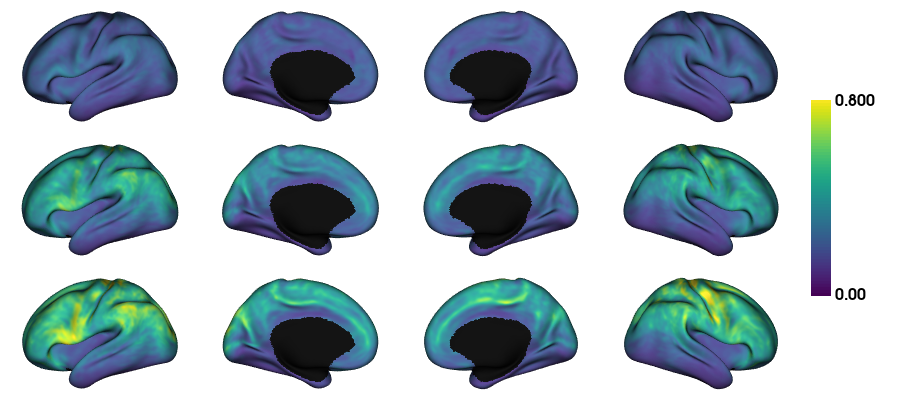

In [9]:
mean_par_SWM[:,mask_32k == False] = np.nan
plot_hemispheres(f32k_inf_lh, f32k_inf_rh, array_name=mean_par_SWM, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.8))

## AFD - perpendicular

In [14]:
all_perp_SWM = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'csd_msmt')
    lh_path = os.path.join(subj_path, 'L_fsLR32k_afd-perp.txt')
    rh_path = os.path.join(subj_path, 'R_fsLR32k_afd-perp.txt')

    try:
        lh_perp = np.loadtxt(lh_path)
        rh_perp = np.loadtxt(rh_path)

        # column 0 (0mm), 2 (1mm), 4 (2mm)
        perp_0mm = np.concatenate((lh_perp[:, 0], rh_perp[:, 0]), axis=0)
        perp_1mm = np.concatenate((lh_perp[:, 2], rh_perp[:, 2]), axis=0)
        perp_2mm = np.concatenate((lh_perp[:, 5], rh_perp[:, 5]), axis=0)

        # Convert -1 to NaN for missing values
        perp_0mm[perp_0mm == -1] = np.nan
        perp_1mm[perp_1mm == -1] = np.nan
        perp_2mm[perp_2mm == -1] = np.nan
        
        perp_SWM = np.vstack([perp_0mm, perp_1mm, perp_2mm])  # shape: (3, vertices)

        # Fill missing data using Turkey's method
        filled_matrix = np.empty_like(perp_SWM)
        for i, row in enumerate(perp_SWM):
            filled_matrix[i] = fill_missing_Turkey(row)

        perp_smooth = smooth_intensities(filled_matrix)
        
        all_perp_SWM.append(perp_smooth)
    except Exception as e:
        print(f"Error loading subject {subj}: {e}")

# shape: (n_subjects, 3, vertices)
all_perp_SWM = np.stack(all_perp_SWM, axis=0)
mean_perp_SWM = np.nanmean(all_perp_SWM, axis=0)  # shape: (3, vertices)

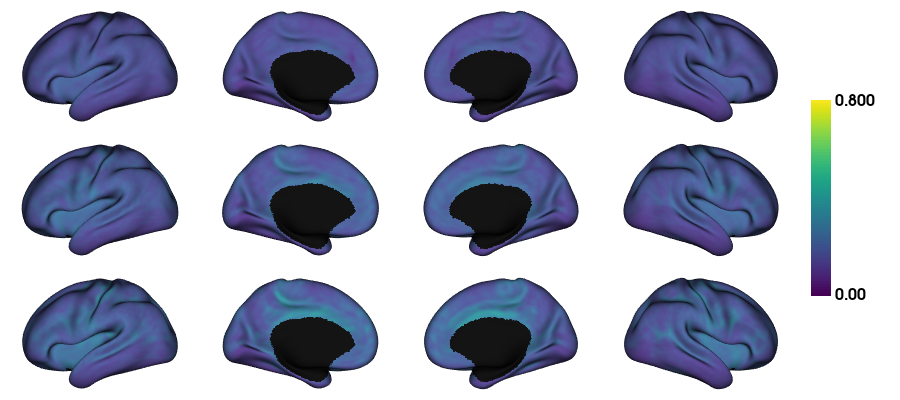

In [15]:
mean_perp_SWM[:,mask_32k == False] = np.nan
plot_hemispheres(f32k_inf_lh, f32k_inf_rh, array_name=mean_perp_SWM, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.8))

## AFD - perpendicular-average (u-fibers)

In [16]:
all_perpav_SWM = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'csd_msmt')
    lh_path = os.path.join(subj_path, 'L_fsLR32k_afd-perp-av.txt')
    rh_path = os.path.join(subj_path, 'R_fsLR32k_afd-perp-av.txt')

    try:
        lh_perpav = np.loadtxt(lh_path)
        rh_perpav = np.loadtxt(rh_path)

        # column 0 (0mm), 2 (1mm), 4 (2mm)
        perpav_0mm = np.concatenate((lh_perpav[:, 0], rh_perpav[:, 0]), axis=0)
        perpav_1mm = np.concatenate((lh_perpav[:, 2], rh_perpav[:, 2]), axis=0)
        perpav_2mm = np.concatenate((lh_perpav[:, 4], rh_perpav[:, 4]), axis=0)

        # Convert -1 to NaN for missing values
        perpav_0mm[perpav_0mm == -1] = np.nan
        perpav_1mm[perpav_1mm == -1] = np.nan
        perpav_2mm[perpav_2mm == -1] = np.nan        
        
        perpav_SWM = np.vstack([perpav_0mm, perpav_1mm, perpav_2mm])  # shape: (3, vertices)

        # Fill missing data using Turkey's method
        filled_matrix = np.empty_like(perpav_SWM)
        for i, row in enumerate(perpav_SWM):
            filled_matrix[i] = fill_missing_Turkey(row)

        perpav_smooth = smooth_intensities(filled_matrix)
        
        all_perpav_SWM.append(perpav_smooth)
    except Exception as e:
        print(f"Error loading subject {subj}: {e}")

# shape: (n_subjects, 3, vertices)
all_perpav_SWM = np.stack(all_perpav_SWM, axis=0)
mean_perpav_SWM = np.nanmean(all_perpav_SWM, axis=0)  # shape: (3, vertices)

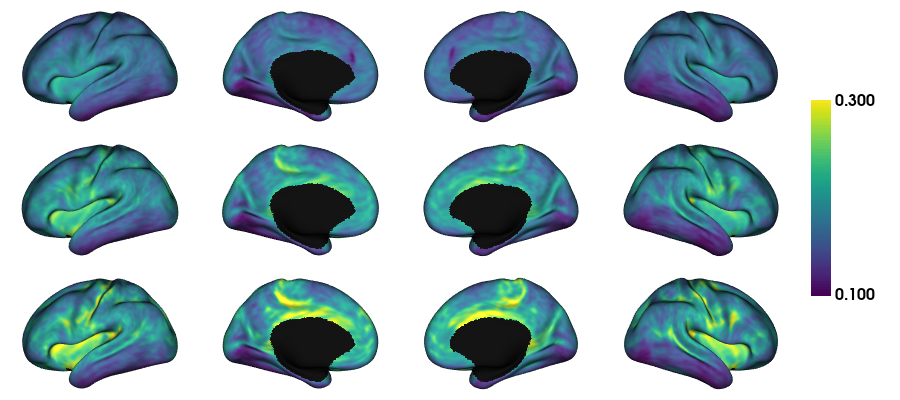

In [23]:
mean_perpav_SWM[:,mask_32k == False] = np.nan
plot_hemispheres(f32k_inf_lh, f32k_inf_rh, array_name=mean_perpav_SWM, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0.1,0.3))